In [1]:
import kagglehub

DATASET_PATH = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

print("Path to dataset files:", DATASET_PATH)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path to dataset files: /kaggle/input/eye-diseases-classification


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 4

In [4]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return enhanced


def segment_blood_vessels(img):
    green = img[:, :, 1]
    blurred = cv2.GaussianBlur(green, (5,5), 0)

    _, vessel_mask = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    vessel_mask = cv2.morphologyEx(vessel_mask, cv2.MORPH_OPEN, kernel)

    return vessel_mask


def segment_optic_disc(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 5)

    mask = np.zeros_like(gray)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=100,
        param1=50,
        param2=30,
        minRadius=30,
        maxRadius=120
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        x, y, r = circles[0][0]
        cv2.circle(mask, (x, y), r, 255, -1)

    return mask


def segment_exudates(img, optic_disc_mask):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray[optic_disc_mask == 255] = 0

    _, exudate_mask = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    exudate_mask = cv2.morphologyEx(exudate_mask, cv2.MORPH_OPEN, kernel)

    return exudate_mask


def combine_segments(img, vessels, optic_disc, exudates):
    combined = np.zeros_like(img)

    combined[vessels == 255] = img[vessels == 255]
    combined[optic_disc == 255] = img[optic_disc == 255]
    combined[exudates == 255] = img[exudates == 255]

    return combined


def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    enhanced = apply_clahe(img)
    vessels = segment_blood_vessels(enhanced)
    optic_disc = segment_optic_disc(enhanced)
    exudates = segment_exudates(enhanced, optic_disc)

    final_img = combine_segments(enhanced, vessels, optic_disc, exudates)

    final_img = preprocess_input(final_img)

    return final_img

In [5]:
class RetinalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=8, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_y = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X, y = [], []

        for path, label in zip(batch_x, batch_y):
            img = preprocess_image(path)

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)

            X.append(img)
            y.append(label)

        return np.array(X), np.array(y)

In [8]:
class_names = [
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "normal"
]

label_map = {cls: idx for idx, cls in enumerate(class_names)}

image_paths = []
labels = []

for cls in class_names:
    folder = os.path.join(DATASET_PATH, "dataset", cls)
    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(label_map[cls])

labels = np.array(labels)

In [9]:
train_p, temp_p, train_l, temp_l = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p,
    temp_l,
    test_size=0.5,
    random_state=42,
    stratify=temp_l
)

train_l = to_categorical(train_l, NUM_CLASSES)
val_l   = to_categorical(val_l, NUM_CLASSES)
test_l  = to_categorical(test_l, NUM_CLASSES)

train_gen = RetinalDataGenerator(train_p, train_l, BATCH_SIZE, augment=True)
val_gen   = RetinalDataGenerator(val_p, val_l, BATCH_SIZE)
test_gen  = RetinalDataGenerator(test_p, test_l, BATCH_SIZE)

In [10]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True


x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 1,825,124 (6.96 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [11]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 201s 447ms/step - accuracy: 0.7255 - loss: 0.7203 - val_accuracy: 0.8813 - val_loss: 0.3362
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 142s 385ms/step - accuracy: 0.8488 - loss: 0.4145 - val_accuracy: 0.9035 - val_loss: 0.2602
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 141s 383ms/step - accuracy: 0.8869 - loss: 0.3158 - val_accuracy: 0.9098 - val_loss: 0.2315
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 122s 331ms/step - accuracy: 0.9164 - loss: 0.2461 - val_accuracy: 0.9082 - val_loss: 0.2311
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 125s 340ms/step - accuracy: 0.9304 - loss: 0.1956 - val_accuracy: 0.9130 - val_loss: 0.2218
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 121s 329ms/step - accuracy: 0.9514 - loss: 0.1445 - val_accuracy: 0.9082 - val_loss: 0.2433
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 123s 335ms/step - accuracy: 0.9599 - loss: 0.1132 - val_accuracy: 0.9051 - val_loss: 0.2520
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 122s 331ms/step - accuracy: 0.9674 -

In [12]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 431ms/step - accuracy: 0.9272 - loss: 0.2041
Test Accuracy: 0.9272152185440063


79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 295ms/step


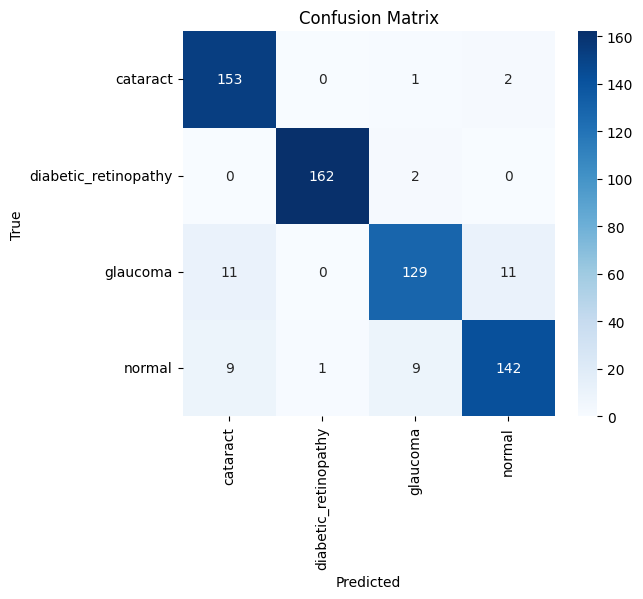


Classification Report:

                      precision    recall  f1-score   support

            cataract     0.8844    0.9808    0.9301       156
diabetic_retinopathy     0.9939    0.9878    0.9908       164
            glaucoma     0.9149    0.8543    0.8836       151
              normal     0.9161    0.8820    0.8987       161

            accuracy                         0.9272       632
           macro avg     0.9273    0.9262    0.9258       632
        weighted avg     0.9282    0.9272    0.9267       632



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_full = np.argmax(test_l, axis=1)
y_true = y_true_full[:len(y_pred)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)